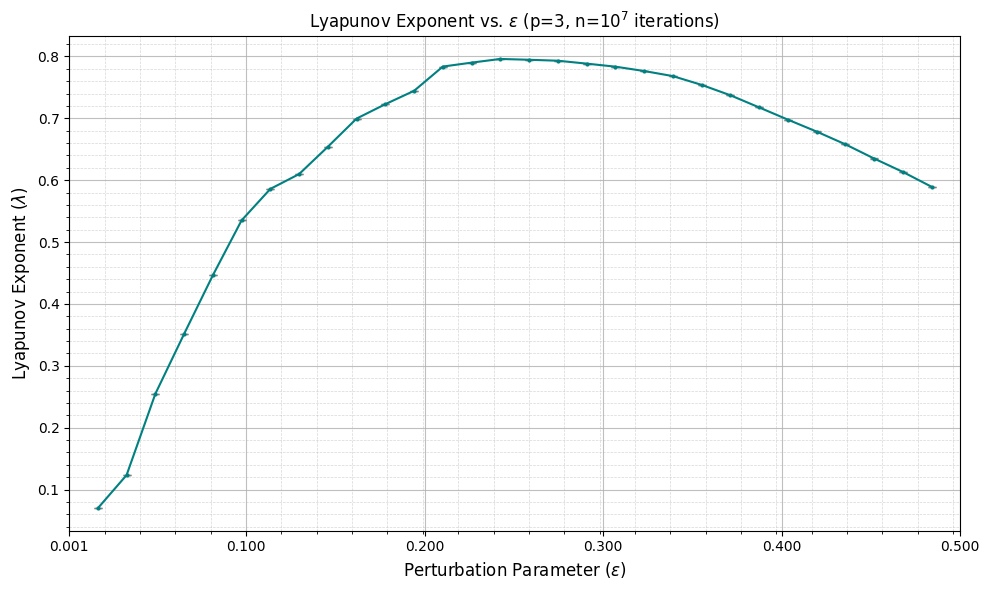

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import numpy as np

# Load the data
df = pd.read_csv('data/epsilon_sweep_20260601_10000000iters_no05.csv')

# Dynamic metadata extraction
m_val = int(df['m'].iloc[0])
n_iters = int(df['iterations'].iloc[0])
eps_min = df['epsilon'].min()
eps_max = df['epsilon'].max()

# Logic for a clean 'n' string
if n_iters < 1_000_000:
    n_str = f"{int(n_iters):,} iterations"
else:
    exponent = int(np.log10(n_iters))
    n_str = rf"$10^{{{exponent}}}$ iterations"

plt.figure(figsize=(10, 6))

# Plotting with connecting lines and error bars
plt.errorbar(
    df['epsilon'], 
    df['lyapunov'], 
    yerr=df['error'], 
    fmt='o-', 
    color='teal', 
    ecolor='gray', 
    elinewidth=1, 
    capsize=3, 
    markersize=2,
    linewidth=1.5
)

# Use the actual values from the CSV for the axis limits
buffer = (eps_max - eps_min) * 0.03
plt.xlim(eps_min - buffer, eps_max + buffer)

# Force the x-ticks to be clean. This prevents Matplotlib from 
# starting the labels at 0.0 if the first point is 0.001.
plt.xticks(ticks=[0.001, 0.1, 0.2, 0.3, 0.4, 0.5])

# Formatting
plt.xlabel(r'Perturbation Parameter ($\epsilon$)', fontsize=12)
plt.ylabel(r'Lyapunov Exponent ($\lambda$)', fontsize=12)
plt.title(f'Lyapunov Exponent vs. $\epsilon$ (p={m_val}, n={n_str})')

plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()

ax = plt.gca() # Get current axes

# Set the number of subdivisions (e.g., 5 subdivisions per major tick)
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

# Turn on the grid for both major and minor ticks
plt.grid(True, which='major', linestyle='-', linewidth=0.8, alpha=0.8)
plt.grid(True, which='minor', linestyle='--', linewidth=0.5, alpha=0.5)

plt.show()